# Breast Cancer Subtype Prediction
# Step 5: Feature Selection - Phase 3 (ReliefF)
# Goal: Select top 150 features using ReliefF algorithm (Context-aware selection).

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import pickle
import os
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

print("✅ Libraries Imported.")

✅ Libraries Imported.


## Define ReliefF Algorithm (Multi-Class Optimized)
Since Scikit-learn does not have ReliefF, we implement a robust version using `NearestNeighbors`.

In [2]:
def reliefF(X, y, n_neighbors=10, n_features_to_select=100):
    """
    ReliefF Algorithm for Multi-Class Feature Selection
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    classes = np.unique(y)
    
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric='manhattan').fit(X)
    distances, indices = nbrs.kneighbors(X)
    
    
    for i in range(n_samples):
        ri = X[i]
        ri_label = y[i]
        
        
        hits = []
        misses = {c: [] for c in classes if c != ri_label}
        
        for neighbor_idx in indices[i][1:]:
            neighbor_label = y[neighbor_idx]
            if neighbor_label == ri_label:
                hits.append(neighbor_idx)
            else:
                if neighbor_label in misses:
                    misses[neighbor_label].append(neighbor_idx)
        
        
        
        for hit_idx in hits:
            weights -= np.abs(ri - X[hit_idx]) / n_samples
            
               
        for c in misses:
            if len(misses[c]) > 0:
                prob_class = len(np.where(y == c)[0]) / n_samples
                diff_sum = np.zeros(n_features)
                for miss_idx in misses[c]:
                    diff_sum += np.abs(ri - X[miss_idx])
                
                weights += (prob_class * diff_sum) / (n_samples * len(misses[c]))

    
    top_indices = np.argsort(weights)[::-1][:n_features_to_select]
    return top_indices, weights

print("✅ ReliefF Function Defined.")

✅ ReliefF Function Defined.


## Define IO Functions

In [3]:
io_dir = '../outputs'

def load_object(filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'rb') as f:
        return pickle.load(f)

def save_object(obj, filename):
    file_path = os.path.join(io_dir, filename + '.pkl')
    with open(file_path, 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    print(f"💾 Saved: {file_path}")

## Load Data (From Step 2 - ANOVA)

In [4]:
print("Loading ANOVA selected data from '../outputs/'...")

try:
    # RNA
    X_train_rna = load_object('X_train_rna_anova')
    X_test_rna = load_object('X_test_rna_anova')
    feat_indices_rna_anova = load_object('feat_indices_rna_anova')
    
    # Methylation
    X_train_meth = load_object('X_train_meth_anova')
    X_test_meth = load_object('X_test_meth_anova')
    feat_indices_meth_anova = load_object('feat_indices_meth_anova')
    
    # Labels
    y_train = load_object('y_train')
    y_test = load_object('y_test')
    
    print("\nData Loaded.")
    print(f"RNA Shape: {X_train_rna.shape}")
    print(f"Meth Shape: {X_train_meth.shape}")
except FileNotFoundError:
    print("❌ Error: Files not found. Run Step 2 (ANOVA) first.")

Loading ANOVA selected data from '../outputs/'...

Data Loaded.
RNA Shape: (439, 48)
Meth Shape: (439, 500)


## 1. Apply ReliefF on RNA
We select the **Top 150** genes. This might take a minute as ReliefF calculates distances between all samples.

In [ ]:
K_RELIEF = 150
print(f"Running ReliefF on RNA (Selecting Top {K_RELIEF})...")

top_rna_indices_local, rna_weights = reliefF(X_train_rna, y_train, n_neighbors=10, n_features_to_select=K_RELIEF)


X_train_rna_relief = X_train_rna[:, top_rna_indices_local]
X_test_rna_relief = X_test_rna[:, top_rna_indices_local]


final_rna_indices = feat_indices_rna_anova[top_rna_indices_local]

print(f"✅ RNA ReliefF Done. Shape: {X_train_rna_relief.shape}")

Running ReliefF on RNA (Selecting Top 150)...
✅ RNA ReliefF Done. Shape: (439, 48)


C:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Temp\ipykernel_4748\2321157181.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ri_label = y[i]
C:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Temp\ipykernel_4748\2321157181.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  neighbor_label = y[neighbor_idx]


## 2. Apply ReliefF on Methylation
We select the **Top 150** methylation sites.

In [6]:
print(f"Running ReliefF on Methylation (Selecting Top {K_RELIEF})...")

top_meth_indices_local, meth_weights = reliefF(X_train_meth, y_train, n_neighbors=10, n_features_to_select=K_RELIEF)

X_train_meth_relief = X_train_meth[:, top_meth_indices_local]
X_test_meth_relief = X_test_meth[:, top_meth_indices_local]

final_meth_indices = feat_indices_meth_anova[top_meth_indices_local]

print(f"✅ Methylation ReliefF Done. Shape: {X_train_meth_relief.shape}")

Running ReliefF on Methylation (Selecting Top 150)...
✅ Methylation ReliefF Done. Shape: (439, 150)


C:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Temp\ipykernel_4748\2321157181.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ri_label = y[i]
C:\Users\HYPER_STOCK_TABRIZ\AppData\Local\Temp\ipykernel_4748\2321157181.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  neighbor_label = y[neighbor_idx]


## Validation: LDA with Top 300 Features
Combining 150 Genes + 150 Methylation sites.

Validating with LDA...

Classification Report (ReliefF Selected Features):
              precision    recall  f1-score   support

        LumA       0.80      0.80      0.80        59
        LumB       0.58      0.56      0.57        25
        Her2       0.62      0.71      0.67         7
       Basal       1.00      1.00      1.00        19

    accuracy                           0.77       110
   macro avg       0.75      0.77      0.76       110
weighted avg       0.77      0.77      0.77       110



<Figure size 600x600 with 0 Axes>

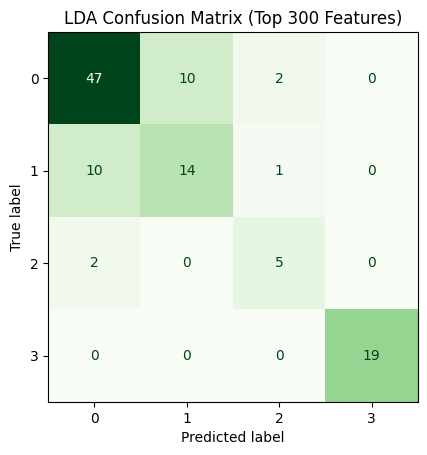

In [7]:
print("Validating with LDA...")

X_train_combined = np.hstack((X_train_rna_relief, X_train_meth_relief))
X_test_combined = np.hstack((X_test_rna_relief, X_test_meth_relief))

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_combined, y_train)
y_pred = lda.predict(X_test_combined)

print("\nClassification Report (ReliefF Selected Features):")
print(classification_report(y_test, y_pred, target_names=['LumA', 'LumB', 'Her2', 'Basal']))

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens', colorbar=False)
plt.title(f"LDA Confusion Matrix (Top {K_RELIEF*2} Features)")
plt.show()

## Saving Result
Saving for the Final Step (mRMR / Classification).

In [ ]:
print("Saving ReliefF selected datasets to '../outputs/'...")

save_object(X_train_rna_relief, 'X_train_rna_relief')
save_object(X_test_rna_relief,  'X_test_rna_relief')
save_object(final_rna_indices, 'feat_indices_rna_relief')

save_object(X_train_meth_relief, 'X_train_meth_relief')
save_object(X_test_meth_relief,  'X_test_meth_relief')
save_object(final_meth_indices, 'feat_indices_meth_relief')

save_object(y_train, 'y_train')
save_object(y_test,  'y_test')

print("\n🎉 Feature Selection Step 3 (ReliefF) Completed.")

Saving ReliefF selected datasets to '../outputs/'...
💾 Saved: ../outputs\X_train_rna_relief.pkl
💾 Saved: ../outputs\X_test_rna_relief.pkl
💾 Saved: ../outputs\feat_indices_rna_relief.pkl
💾 Saved: ../outputs\X_train_meth_relief.pkl
💾 Saved: ../outputs\X_test_meth_relief.pkl
💾 Saved: ../outputs\feat_indices_meth_relief.pkl
💾 Saved: ../outputs\y_train.pkl
💾 Saved: ../outputs\y_test.pkl

🎉 Feature Selection Step 3 (ReliefF) Completed.
